In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
df1 = pd.read_excel('example_data.xlsx', sheet_name=1)
df2 = pd.read_excel('example_data.xlsx', sheet_name=2)

In [3]:
df1.head()

,X1,X2,X3,X4
0,450,250,8,25
1,450,250,8,35
2,450,250,12,25
3,450,250,12,35
4,450,350,8,25


In [4]:
df2.head()

,weight (kg),deflection (mm),stress (GPa),1st Natural frequency (Hz)
0,0.70471,0.004877,3.8037,239.68
1,0.96177,0.003859,3.5991,238.12
2,1.05710,0.001502,2.9072,356.54
3,1.44270,0.001191,2.8308,352.43
4,0.81551,0.004993,3.9157,239.62


In [5]:
degree = 2

poly_features  = PolynomialFeatures(degree=degree, include_bias=True)
X_train_poly = poly_features.fit_transform(df1)

In [6]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, df2.iloc[:,0])
print('intercept : ',lin_reg.intercept_,', coef:' , lin_reg.coef_[1:])

intercept :  1.2319134375006207 , coef: [-1.66278750e-03 -1.66272083e-03 -1.25068021e-01 -3.76772917e-02
  1.04166667e-09  1.74999999e-09  1.66168750e-04  5.53825000e-05
  1.04166667e-09  1.66168750e-04  5.53825000e-05  9.63541667e-07
  3.76606250e-03 -1.10295833e-04]


* parameters 순서: 상수항, $(X1, X2, X3, X4), (X1^2, X1*X2, X1*X3, X1*X4), (X2^2, X2*X3, X2*X4)$ ... 

In [7]:
X_new=df1
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

In [8]:
def r2_score(y_true, y_pred):

    # 1. 평균값 계산
    y_mean = sum(y_true) / len(y_true)

    # . SST, SSE, SSR 계산
    sst = sum([(y - y_mean)**2 for y in y_true])
    ssr = sum([(y_mean - pred)**2 for pred in y_pred])
    sse = sum([(y - pred)**2 for y, pred in zip(y_true, y_pred)])

    # 3. R2 계산 (음수 가능) → 음수가 싫을 경우, 아래 수식 변경
    r2 = 1 - (sse / sst)

    return r2, sst, sse, ssr

# 예시 데이터
np.random.seed(0) # 결과의 일관성을 위해 seed를 설정합니다.
y_true = df2.iloc[:,0]
y_pred = y_new

# R2, SST, SSE, SSR 계산
r2, sst, sse, ssr = r2_score(y_true, y_pred) 

# 결과 출력
print(f"R2 점수: {r2}")
print(f"SST: {sst}")
print(f"SSE: {sse}")
print(f"SSR: {ssr}")

R2 점수: 0.9999060225039998
SST: 2.623509018936
SSE: 0.0002465508083333347
SSR: 2.623262468128049


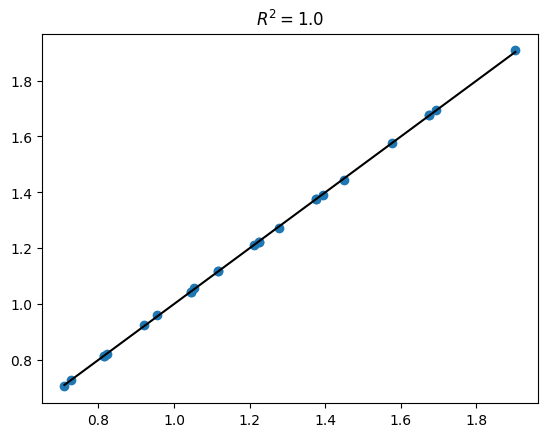

In [9]:
plt.plot([min(y_new),max(y_new)],[min(y_new),max(y_new)], 'k')
plt.scatter(y_new, df2.iloc[:,0])
plt.title('$R^2 = {}$'.format(np.round(r2, 3)))
plt.show()

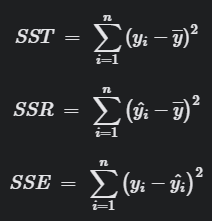